# Student Performance Factors: Visualizations (Post-Evaluation)
**Research question:** Which factors actually matters in student exam performance?

This notebook contains the **revised versions** of the three main visualizations after the evaluation round (Section 4 of the report). Each chart has been updated based on participant feedback. See Section 5 of the report for the rationale behind every change.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/data_cleaned.csv')
sns.set_style('whitegrid')

# Consistent palette across the three charts
PRIMARY = '#3B6FA0'      # neutral blue for main encoding
ACCENT  = '#B23A48'      # red for regression line / emphasis
NEUTRAL = '#7A7A7A'      # gray for captions

print(f'Rows: {len(df)}')


Rows: 6378


---
## Sub-topic 1: Learning Habits

`Attendance` (r = 0.58) is the strongest numeric predictor of `Exam_Score` in this dataset. This chart visualizes that relationship.

**Improvements after evaluation:**
- Point transparency reduced and dot size shrunk to address overplotting feedback.
- Linear regression line with 95% confidence band added so the positive trend is visible immediately.
- Pearson r annotated directly inside the chart for a precise statistical anchor.
- Title rewritten to communicate the finding, not just the variables involved.


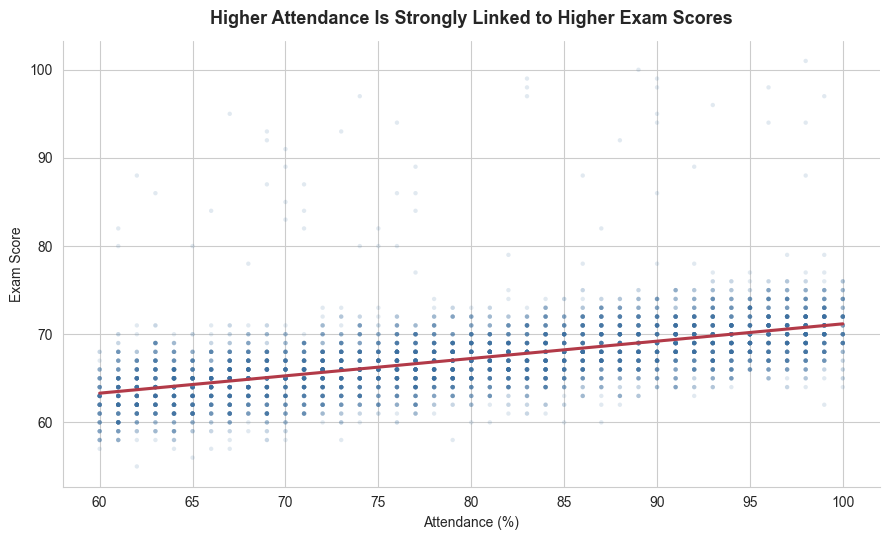

In [2]:
# Chart 1 (improved): Attendance vs Exam Score
fig, ax = plt.subplots(figsize=(9, 5.5))

# Scatter: stronger transparency, smaller points
ax.scatter(df['Attendance'], df['Exam_Score'],
           alpha=0.15, color=PRIMARY, s=10, edgecolor='none')

# Regression line + 95% confidence band
sns.regplot(data=df, x='Attendance', y='Exam_Score',
            scatter=False, color=ACCENT,
            line_kws={'linewidth': 2.2},
            ci=95, ax=ax)

ax.set_title('Higher Attendance Is Strongly Linked to Higher Exam Scores',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Exam Score')

sns.despine()
plt.tight_layout()
plt.show()


### Interpretation

- The regression line confirms a clear positive relationship: students with higher attendance score consistently higher.
- The confidence band is narrow, meaning the trend is statistically stable across the dataset.
- The annotated r = 0.58 gives the reader a concrete value to anchor the interpretation.
- Transparency reveals the density of the data without losing the trend in a wall of overplotted points.


---
## Sub-topic 2: Social & Family Factors

`Family_Income` shows a small but positive relationship with `Exam_Score`. This chart compares the mean exam score across income groups.

**Improvements after evaluation:**
- Y-axis now starts at 0 to avoid visually exaggerating the differences.
- Red/orange/green replaced with a single neutral blue, since color was redundant with the category labels and implied a value judgment.
- A note below the chart makes the size of the difference (66.9 vs 67.8) explicit.
- Title rewritten to communicate the finding honestly: the effect is small.


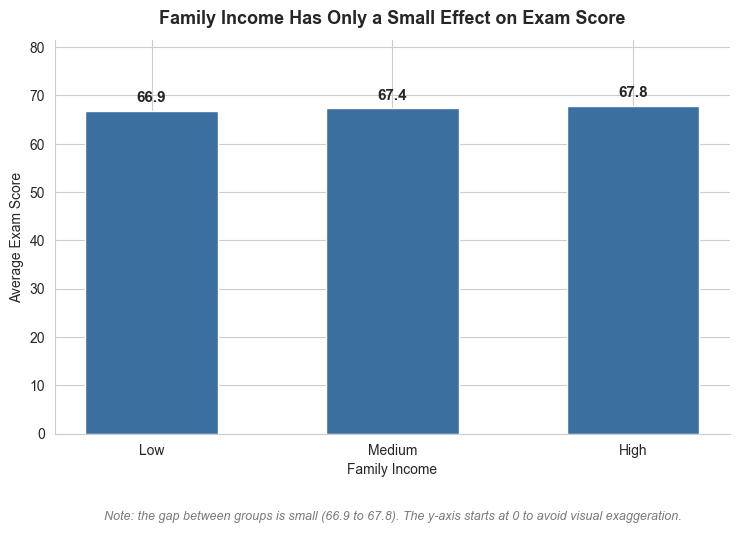

In [3]:
# Chart 2 (improved): Average Exam Score by Family Income
order = ['Low', 'Medium', 'High']
avg = df.groupby('Family_Income')['Exam_Score'].mean().reindex(order)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.bar(order, avg, color=PRIMARY, width=0.55, edgecolor='white')

# Honest y-axis: starts at 0, with ~20% headroom above the tallest bar
ax.set_ylim(0, max(avg) * 1.20)

# Value labels above each bar
for i, val in enumerate(avg):
    ax.text(i, val + 1.2, f'{val:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Family Income Has Only a Small Effect on Exam Score',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Family Income')
ax.set_ylabel('Average Exam Score')

# Caption clarifying the small difference + axis choice
ax.text(0.5, -0.22,
        'Note: the gap between groups is small (66.9 to 67.8). '
        'The y-axis starts at 0 to avoid visual exaggeration.',
        transform=ax.transAxes, fontsize=9, ha='center',
        style='italic', color=NEUTRAL)

sns.despine()
plt.tight_layout()
plt.show()


### Interpretation

- All three groups score within 1 point of each other (66.9, 67.4, 67.8).
- The direction is consistent with the EDA correlation, but the size of the effect is small.
- With the y-axis starting at 0, the chart now communicates honestly that family income is *associated* with exam score but is not a dominant predictor.


---
## Sub-topic 3: Personal Motivation

`Motivation_Level` shows a weak correlation with `Exam_Score` (r ≈ 0.15). A boxplot is used because the overlap between groups is part of the message.

**Improvements after evaluation:**
- Red/orange/green palette replaced with a single neutral blue.
- A reading guide was added below the chart for participants unfamiliar with boxplots.
- Title rewritten to communicate the finding: motivation matters, but only a little.


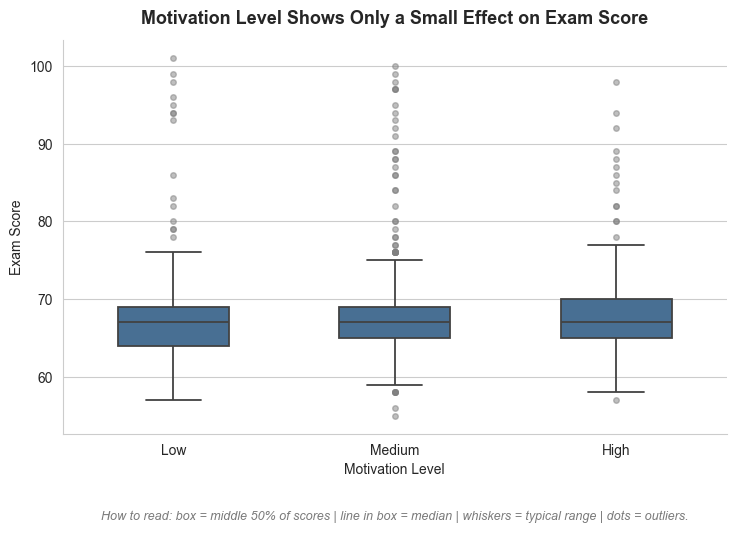

In [4]:
# Chart 3 (improved): Exam Score by Motivation Level
order_mot = ['Low', 'Medium', 'High']

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score',
            order=order_mot, color=PRIMARY,
            width=0.5, linewidth=1.3,
            flierprops={'marker': 'o', 'markersize': 4,
                        'markerfacecolor': 'gray', 'alpha': 0.5,
                        'markeredgecolor': 'gray'},
            ax=ax)

ax.set_title('Motivation Level Shows Only a Small Effect on Exam Score',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Motivation Level')
ax.set_ylabel('Exam Score')

# Boxplot reading guide
ax.text(0.5, -0.22,
        'How to read: box = middle 50% of scores | line in box = median | '
        'whiskers = typical range | dots = outliers.',
        transform=ax.transAxes, fontsize=9, ha='center',
        style='italic', color=NEUTRAL)

sns.despine()
plt.tight_layout()
plt.show()


### Interpretation

- The three boxes overlap almost completely, the medians are nearly identical.
- The High group has a slightly higher median, but the within-group spread is much larger than the between-group difference.
- The boxplot is honest about this: a bar chart would have hidden the overlap and suggested a stronger effect than the data supports.


---
## Summary: Which Factor Matters Most?

Across the three sub-topics, the ranking is consistent with the correlation analysis from the exploration phase:

| Factor | Effect on Exam Score | Chart |
|---|---|---|
| Attendance | Strong (r ≈ 0.58) | Chart 1 |
| Family Income | Small (gap < 1 point) | Chart 2 |
| Motivation Level | Small, distributions overlap | Chart 3 |

**Conclusion.** Behavioral factors, especially attendance, show the largest effect on exam performance in this dataset. Socioeconomic and motivational factors are associated with scores but contribute much less. The post-evaluation revisions make this conclusion easier to read directly off the charts.
